# **Neural Network (MLP) — Hotel Booking Cancellation Prediction**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Import Libararies**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, label_binarize, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, f1_score,
                             recall_score, precision_score)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("All libraries imported successfully")

All libraries imported successfully


---
## **Preprocessing**

Unlike RF and XGBoost, neural networks require:
- **Log transform** for skewed features (Lead_Time_Days, Total_Bill_amount, Babies)
- **StandardScaler** to normalise all features to mean=0, std=1

In [5]:
train = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_train.csv")
val   = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_validation.csv")
test  = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_test.csv")

# Log Transform (needed for MLP — reduces skewness)
log_cols = ["Lead_Time_Days", "Total_Bill_amount", "Babies"]
for col in log_cols:
    train[f"{col}_log"] = np.log1p(train[col])
    val[f"{col}_log"]   = np.log1p(val[col])
    test[f"{col}_log"]  = np.log1p(test[col])
    train.drop(columns=[col], inplace=True)
    val.drop(columns=[col],   inplace=True)
    test.drop(columns=[col],  inplace=True)

print("Log transform done")

# Binary Encoding
binary_cols = ["Gender", "Previous_Cancellations", "Visted_Previously",
               "Use_Promotion", "Required_Car_Parking"]
le = LabelEncoder()
for col in binary_cols:
    le.fit(train[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

# Ordinal Encoding
income_order = [["<25K", "25K --50K", "50K -- 100K", ">100K"]]
edu_order    = [["Mid-School", "High-School", "College", "Grad"]]

oe_income = OrdinalEncoder(categories=income_order,
                            handle_unknown="use_encoded_value", unknown_value=-1)
oe_income.fit(train[["Income"]])
train["Income"] = oe_income.transform(train[["Income"]])
val["Income"]   = oe_income.transform(val[["Income"]])
test["Income"]  = oe_income.transform(test[["Income"]])

oe_edu = OrdinalEncoder(categories=edu_order,
                         handle_unknown="use_encoded_value", unknown_value=-1)
oe_edu.fit(train[["Educational_Level"]])
train["Educational_Level"] = oe_edu.transform(train[["Educational_Level"]])
val["Educational_Level"]   = oe_edu.transform(val[["Educational_Level"]])
test["Educational_Level"]  = oe_edu.transform(test[["Educational_Level"]])

# Target Encoding for Meal_Type
meal_target_map = (
    train.groupby("Meal_Type")["Reservation_Status"]
    .apply(lambda x: (x != "Check-In").mean())
    .to_dict()
)
train["Meal_Type"] = train["Meal_Type"].map(meal_target_map)
val["Meal_Type"]   = val["Meal_Type"].map(meal_target_map)
test["Meal_Type"]  = test["Meal_Type"].map(meal_target_map).fillna(
    train["Meal_Type"].mean())

# OHE
ohe_cols = ["Hotel_Type", "Booking_channel", "Deposit_type",
            "Ethnicity", "Country_region"]
train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
val   = pd.get_dummies(val,   columns=ohe_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

for frame in [train, val, test]:
    frame.columns = frame.columns.str.replace("[","",regex=False)\
                                  .str.replace("]","",regex=False)\
                                  .str.replace("<","",regex=False)\
                                  .str.replace(">","",regex=False)\
                                  .str.replace(",","",regex=False)\
                                  .str.replace(" ","_",regex=False)\
                                  .str.replace("-","_",regex=False)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

Log transform done
Train: (17694, 35) | Val: (1784, 35) | Test: (2793, 35)


---
## **Encode Target & Prepare X, y + StandardScaler**

In [6]:
le_target = LabelEncoder()
le_target.fit(train["Reservation_Status"])

y_train = le_target.transform(train["Reservation_Status"])
y_val   = le_target.transform(val["Reservation_Status"])

print("Classes:", le_target.classes_)

drop_cols = [c for c in ["Reservation_Status", "Booking_date",
                          "Expected_checkin", "Expected_checkout",
                          "Reservation_ID"]
             if c in train.columns]

X_train_raw = train.drop(columns=drop_cols).astype(float)
X_val_raw   = val.drop(columns=drop_cols).astype(float)
X_test_raw  = test.drop(columns=[c for c in drop_cols
                                  if c in test.columns]).astype(float)

# StandardScaler — fit on train only, transform all
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw),
                        columns=X_train_raw.columns, index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val_raw),
                        columns=X_val_raw.columns, index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),
                        columns=X_test_raw.columns, index=X_test_raw.index)

y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"\nScaler fitted — mean of first 3 features: {scaler.mean_[:3].round(3)}")

print("\nTrain class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nVal class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_val == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_val)*100:.1f}%)")

Classes: ['Canceled' 'Check-In' 'No-Show']
X_train: (17694, 34) | X_val: (1784, 34) | X_test: (2793, 34)

Scaler fitted — mean of first 3 features: [ 0.499 43.962  1.603]

Train class distribution:
  Canceled: 2724 (15.4%)
  Check-In: 13604 (76.9%)
  No-Show: 1366 (7.7%)

Val class distribution:
  Canceled: 491 (27.5%)
  Check-In: 1041 (58.4%)
  No-Show: 252 (14.1%)


---
## **Evaluation Function**

In [7]:
def evaluate_model(name, y_true, y_pred, y_prob, y_true_bin, classes):

    acc       = round(accuracy_score(y_true, y_pred), 4)
    prec      = round(precision_score(y_true, y_pred,
                      average="macro", zero_division=0), 4)
    recall    = round(recall_score(y_true, y_pred, average="macro"), 4)
    f1        = round(f1_score(y_true, y_pred, average="macro"), 4)
    auc       = round(roc_auc_score(y_true_bin, y_prob,
                      multi_class="ovr"), 4)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc}")
    print(f"  Precision : {prec}")
    print(f"  Recall    : {recall}")
    print(f"  F1 Macro  : {f1}")
    print(f"  ROC-AUC   : {auc}")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=classes)
    plt.figure(figsize=(8, 6))
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {name}", fontsize=13)
    plt.tight_layout()
    plt.show()

    colors = ["steelblue", "orange", "green"]
    plt.figure(figsize=(9, 6))
    for i, (color, cls) in enumerate(zip(colors, classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_cls = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{cls} (AUC={auc_cls:.3f})")
    plt.plot([0,1],[0,1],"r--", label="Random Guess")
    plt.title(f"ROC Curve — {name}", fontsize=13)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": recall, "f1_macro": f1, "roc_auc": auc}

print("Evaluation function ready")

Evaluation function ready


---
## **Prepare Sampled Datasets**

In [8]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

oversample_exact = SMOTE(sampling_strategy={0: 2750, 2: 1410},
                          random_state=42, k_neighbors=5)
undersample_exact = RandomUnderSampler(sampling_strategy={1: 5840},
                                        random_state=42)
exact_pipe = Pipeline([("smote", oversample_exact), ("undersample", undersample_exact)])
X_train_exact, y_train_exact = exact_pipe.fit_resample(X_train, y_train)

print(f"SMOTE: {len(X_train_smote)} | Undersampling: {len(X_train_rus)} | Exact Match: {len(X_train_exact)}")

SMOTE: 40812 | Undersampling: 4098 | Exact Match: 10000


---
## **Sampling Strategy Comparison**

MLP architecture: 128→64→32 neurons, ReLU activation, Adam optimiser, early stopping enabled.

In [9]:
results = []


  MLP Baseline
  Accuracy  : 0.5835
  Precision : 0.1945
  Recall    : 0.3333
  F1 Macro  : 0.2457
  ROC-AUC   : 0.5123

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.00      0.00      0.00       491
    Check-In       0.58      1.00      0.74      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.19      0.33      0.25      1784
weighted avg       0.34      0.58      0.43      1784



<Figure size 800x600 with 0 Axes>

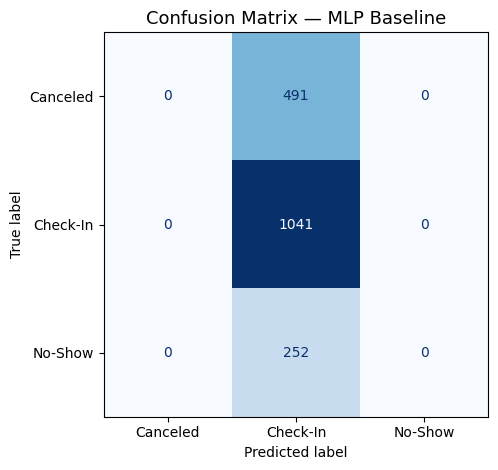

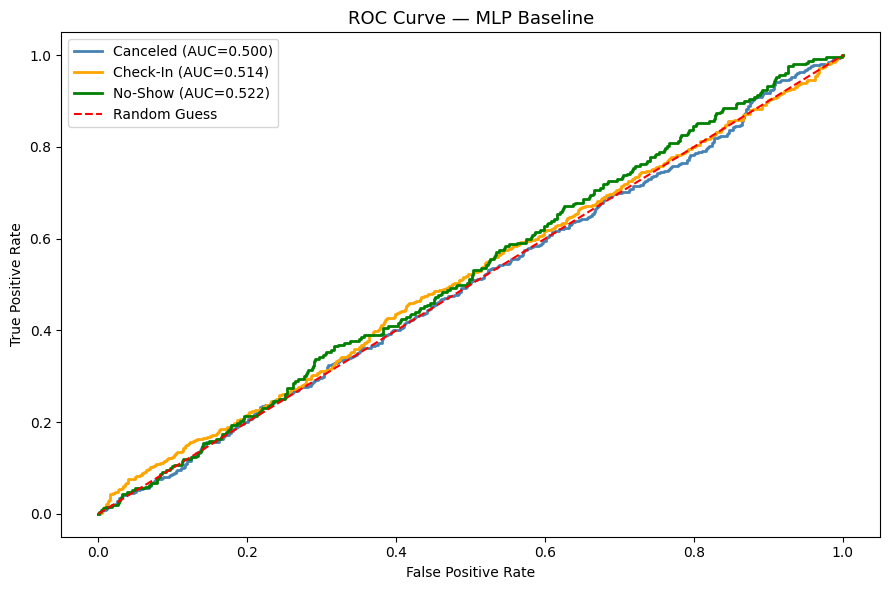

Converged in 17 iterations


In [10]:
# Baseline
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam",
    alpha=0.001, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_baseline.fit(X_train, y_train)
y_pred = mlp_baseline.predict(X_val)
y_prob = mlp_baseline.predict_proba(X_val)
metrics = evaluate_model("MLP Baseline", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_baseline.n_iter_} iterations")


  MLP SMOTE
  Accuracy  : 0.472
  Precision : 0.3405
  Recall    : 0.3402
  F1 Macro  : 0.3372
  ROC-AUC   : 0.5058

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.27      0.20      0.23       491
    Check-In       0.59      0.68      0.63      1041
     No-Show       0.16      0.14      0.15       252

    accuracy                           0.47      1784
   macro avg       0.34      0.34      0.34      1784
weighted avg       0.44      0.47      0.45      1784



<Figure size 800x600 with 0 Axes>

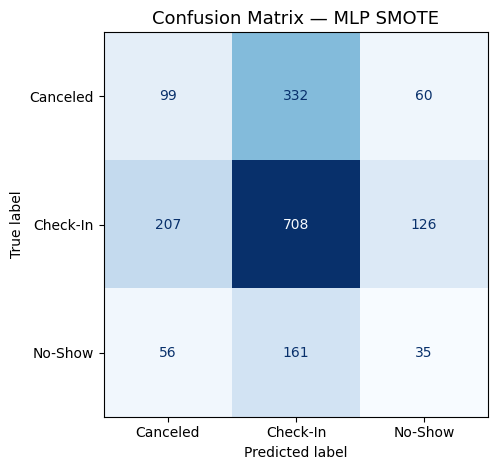

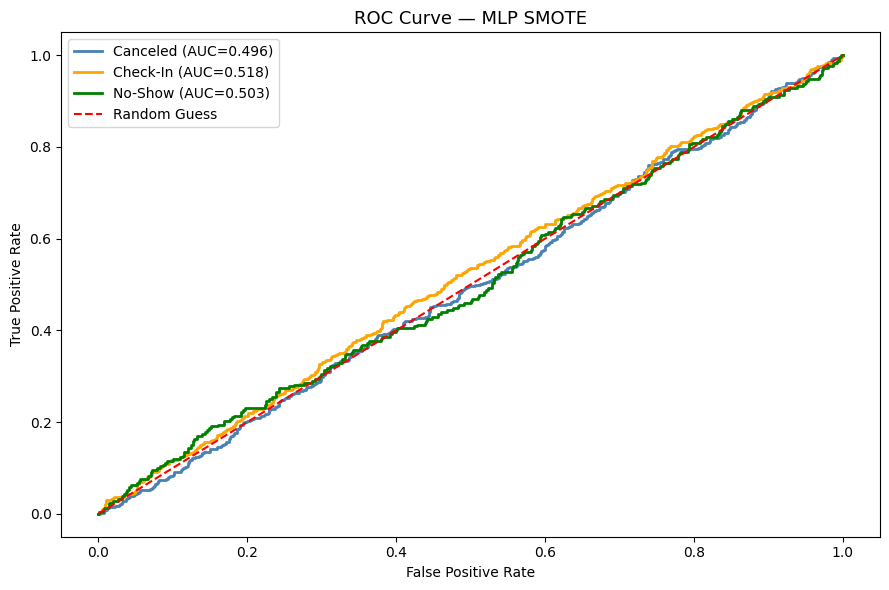

Converged in 80 iterations


In [11]:
# SMOTE
mlp_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam",
    alpha=0.001, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_smote.fit(X_train_smote, y_train_smote)
y_pred = mlp_smote.predict(X_val)
y_prob = mlp_smote.predict_proba(X_val)
metrics = evaluate_model("MLP SMOTE", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_smote.n_iter_} iterations")


  MLP Undersampling
  Accuracy  : 0.3795
  Precision : 0.3374
  Recall    : 0.3372
  F1 Macro  : 0.3276
  ROC-AUC   : 0.5147

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.26      0.31      0.29       491
    Check-In       0.60      0.44      0.51      1041
     No-Show       0.15      0.26      0.19       252

    accuracy                           0.38      1784
   macro avg       0.34      0.34      0.33      1784
weighted avg       0.44      0.38      0.40      1784



<Figure size 800x600 with 0 Axes>

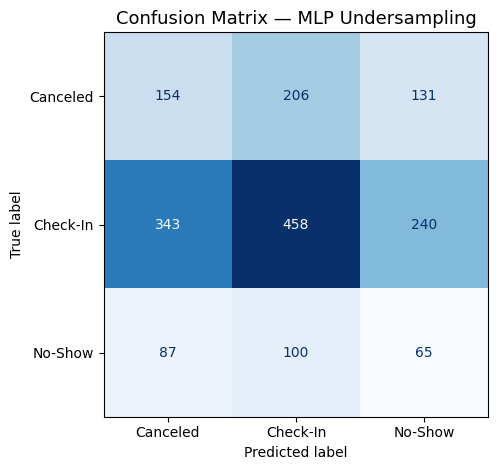

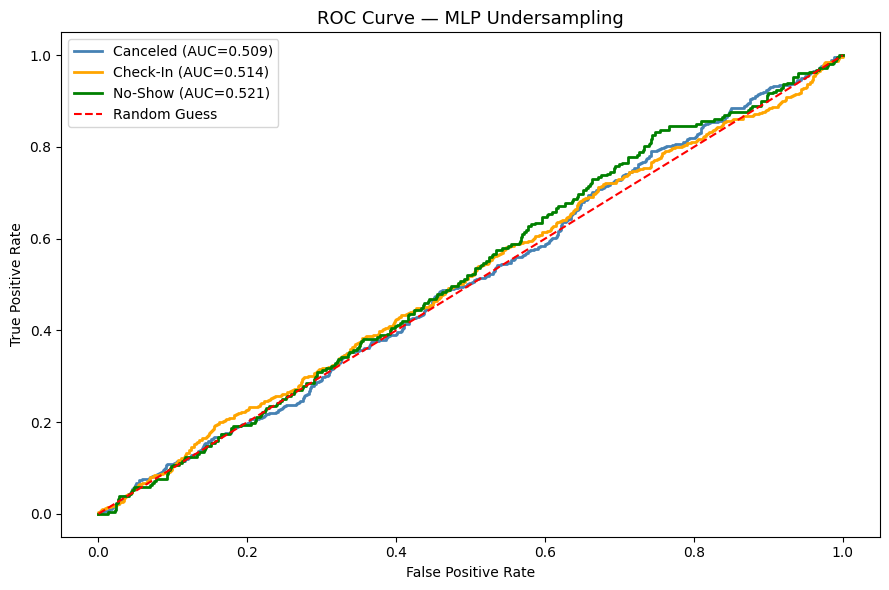

Converged in 17 iterations


In [12]:
# Undersampling
mlp_rus = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam",
    alpha=0.001, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_rus.fit(X_train_rus, y_train_rus)
y_pred = mlp_rus.predict(X_val)
y_prob = mlp_rus.predict_proba(X_val)
metrics = evaluate_model("MLP Undersampling", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_rus.n_iter_} iterations")


  MLP Exact Val Match
  Accuracy  : 0.5566
  Precision : 0.2829
  Recall    : 0.3309
  F1 Macro  : 0.2755
  ROC-AUC   : 0.5177

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.27      0.07      0.12       491
    Check-In       0.58      0.92      0.71      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.56      1784
   macro avg       0.28      0.33      0.28      1784
weighted avg       0.41      0.56      0.45      1784



<Figure size 800x600 with 0 Axes>

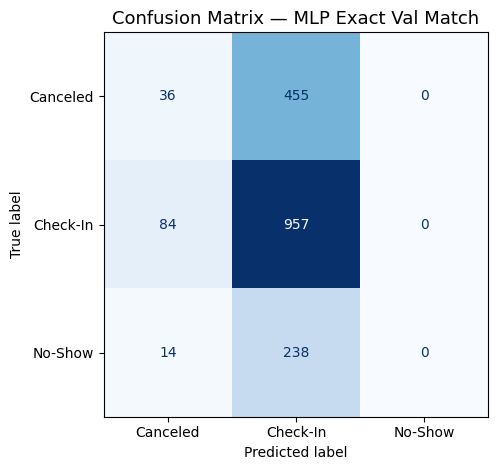

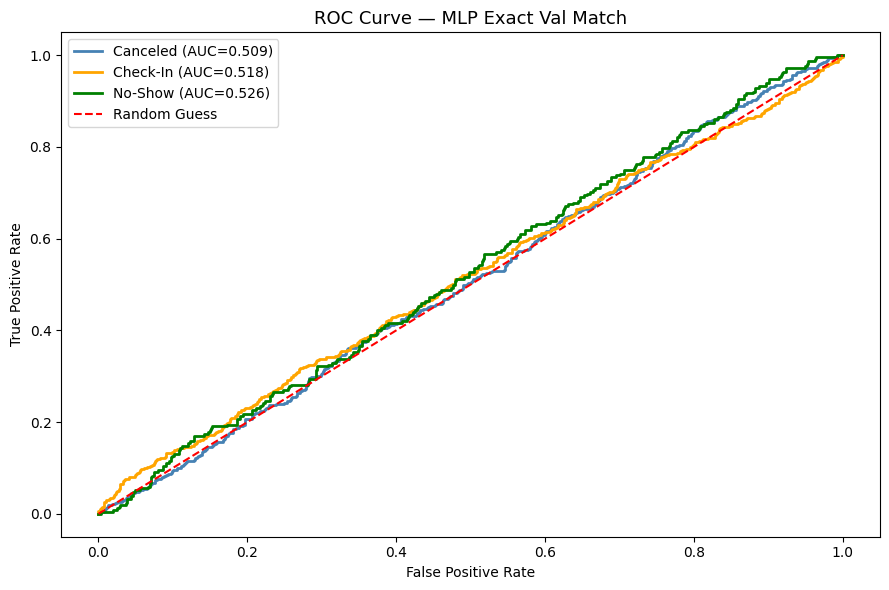

Converged in 17 iterations


In [13]:
# Exact Validation Distribution Match
mlp_exact = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam",
    alpha=0.001, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_exact.fit(X_train_exact, y_train_exact)
y_pred = mlp_exact.predict(X_val)
y_prob = mlp_exact.predict_proba(X_val)
metrics = evaluate_model("MLP Exact Val Match", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_exact.n_iter_} iterations")


  MLP Exact + Deeper
  Accuracy  : 0.5566
  Precision : 0.2926
  Recall    : 0.3377
  F1 Macro  : 0.2912
  ROC-AUC   : 0.5185

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.11      0.16       491
    Check-In       0.59      0.90      0.71      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.56      1784
   macro avg       0.29      0.34      0.29      1784
weighted avg       0.42      0.56      0.46      1784



<Figure size 800x600 with 0 Axes>

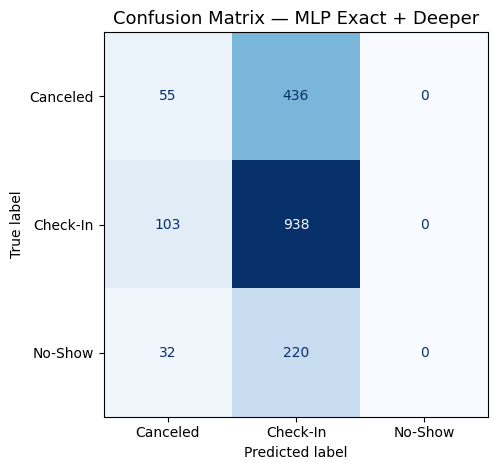

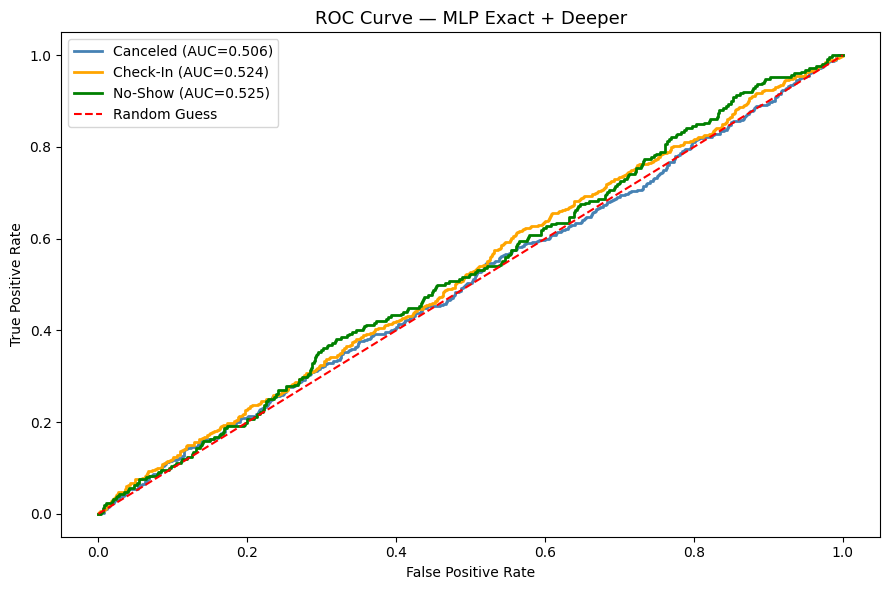

Converged in 19 iterations


In [14]:
# Exact Val Match + Sample Weights
# MLP doesn't have class_weight param but we can use sample_weight in a
# custom training loop. However sklearn MLPClassifier doesn't support
# sample_weight directly — so we simulate it by oversampling weighted classes more
# This is already handled by the exact match sampling above.
# Instead, we try a different architecture with more capacity

mlp_exact_deep = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32), activation="relu", solver="adam",
    alpha=0.0005, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_exact_deep.fit(X_train_exact, y_train_exact)
y_pred = mlp_exact_deep.predict(X_val)
y_prob = mlp_exact_deep.predict_proba(X_val)
metrics = evaluate_model("MLP Exact + Deeper", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_exact_deep.n_iter_} iterations")


  MLP Undersample + Deeper
  Accuracy  : 0.333
  Precision : 0.3449
  Recall    : 0.3398
  F1 Macro  : 0.3089
  ROC-AUC   : 0.5173

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.30      0.27      0.28       491
    Check-In       0.60      0.35      0.44      1041
     No-Show       0.14      0.40      0.21       252

    accuracy                           0.33      1784
   macro avg       0.34      0.34      0.31      1784
weighted avg       0.45      0.33      0.36      1784



<Figure size 800x600 with 0 Axes>

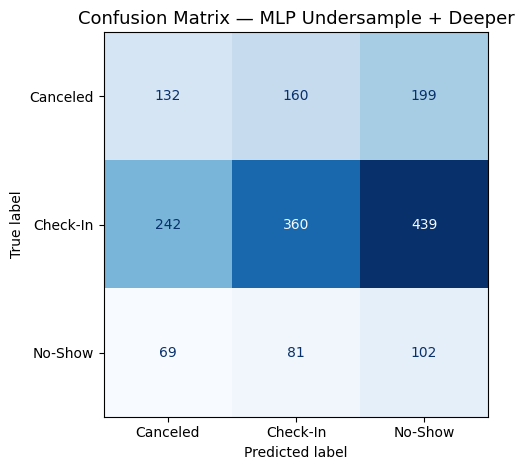

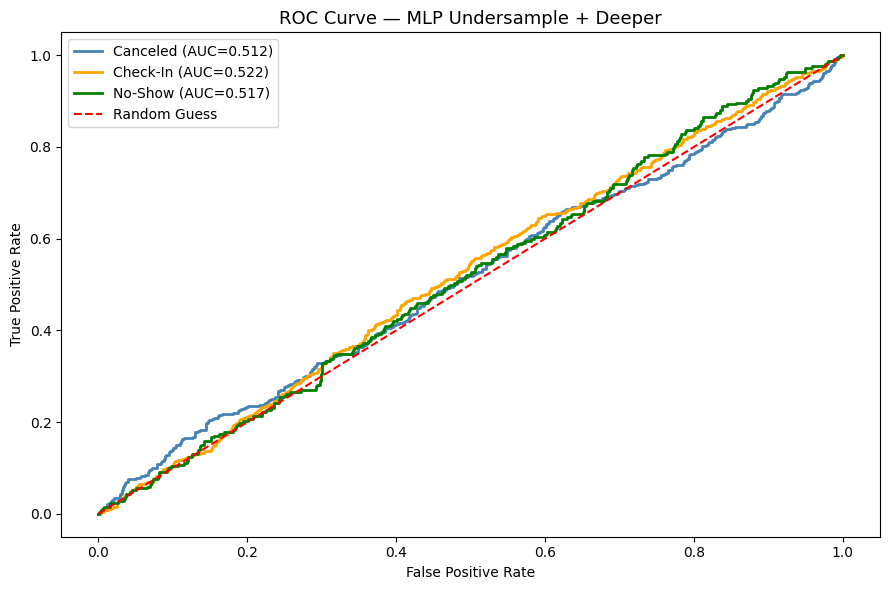

Converged in 17 iterations


In [15]:
# Undersampling + Deeper architecture
mlp_rus_deep = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32), activation="relu", solver="adam",
    alpha=0.0005, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_rus_deep.fit(X_train_rus, y_train_rus)
y_pred = mlp_rus_deep.predict(X_val)
y_prob = mlp_rus_deep.predict_proba(X_val)
metrics = evaluate_model("MLP Undersample + Deeper", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_rus_deep.n_iter_} iterations")


  MLP SMOTE + Deeper
  Accuracy  : 0.5039
  Precision : 0.3313
  Recall    : 0.3297
  F1 Macro  : 0.3124
  ROC-AUC   : 0.4922

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.24      0.12      0.16       491
    Check-In       0.58      0.79      0.67      1041
     No-Show       0.18      0.08      0.11       252

    accuracy                           0.50      1784
   macro avg       0.33      0.33      0.31      1784
weighted avg       0.43      0.50      0.45      1784



<Figure size 800x600 with 0 Axes>

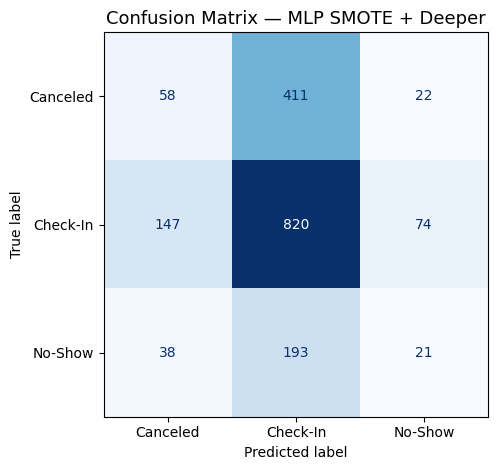

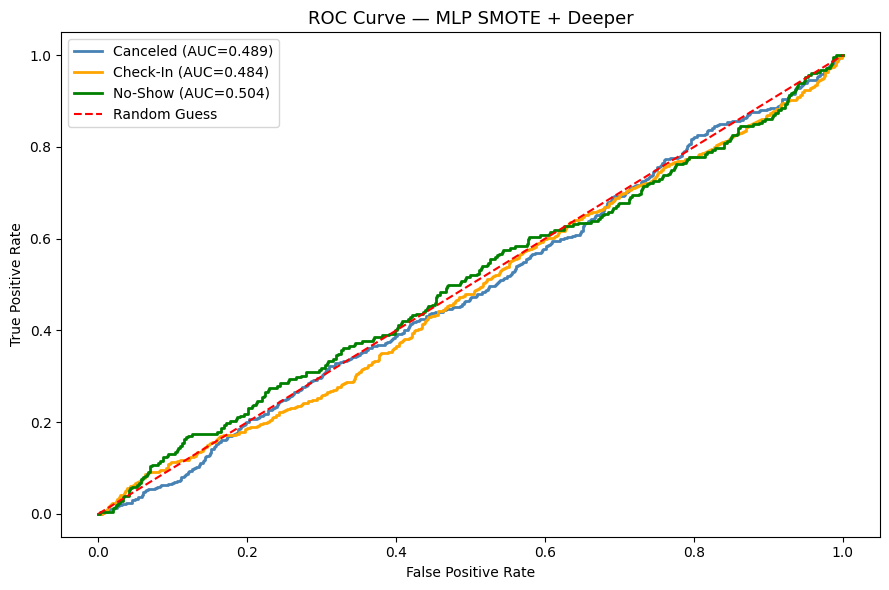

Converged in 79 iterations


In [16]:
# SMOTE + Deeper architecture
mlp_smote_deep = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32), activation="relu", solver="adam",
    alpha=0.0005, batch_size=64, learning_rate="adaptive",
    max_iter=300, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=15
)

mlp_smote_deep.fit(X_train_smote, y_train_smote)
y_pred = mlp_smote_deep.predict(X_val)
y_prob = mlp_smote_deep.predict_proba(X_val)
metrics = evaluate_model("MLP SMOTE + Deeper", y_val, y_pred, y_prob, y_val_bin, le_target.classes_)
results.append(metrics)
print(f"Converged in {mlp_smote_deep.n_iter_} iterations")

---
## **Sampling Comparison Table**

In [17]:
results_df = pd.DataFrame(results)

print("=" * 95)
print("       MLP — SAMPLING METHOD COMPARISON")
print("=" * 95)
print(f"{'Model':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1 Macro':>9} {'ROC-AUC':>9}")
print("-" * 95)
for _, row in results_df.iterrows():
    print(f"{row['name']:<28} {row['accuracy']:>9} {row['precision']:>10} {row['recall']:>8} {row['f1_macro']:>9} {row['roc_auc']:>9}")
print("=" * 95)

print(f"\nBest by F1 Macro:  {results_df.loc[results_df['f1_macro'].idxmax(), 'name']} ({results_df['f1_macro'].max()})")
print(f"Best by Recall:    {results_df.loc[results_df['recall'].idxmax(), 'name']} ({results_df['recall'].max()})")
print(f"Best by ROC-AUC:   {results_df.loc[results_df['roc_auc'].idxmax(), 'name']} ({results_df['roc_auc'].max()})")

       MLP — SAMPLING METHOD COMPARISON
Model                         Accuracy  Precision   Recall  F1 Macro   ROC-AUC
-----------------------------------------------------------------------------------------------
MLP Baseline                    0.5835     0.1945   0.3333    0.2457    0.5123
MLP SMOTE                        0.472     0.3405   0.3402    0.3372    0.5058
MLP Undersampling               0.3795     0.3374   0.3372    0.3276    0.5147
MLP Exact Val Match             0.5566     0.2829   0.3309    0.2755    0.5177
MLP Exact + Deeper              0.5566     0.2926   0.3377    0.2912    0.5185
MLP Undersample + Deeper         0.333     0.3449   0.3398    0.3089    0.5173
MLP SMOTE + Deeper              0.5039     0.3313   0.3297    0.3124    0.4922

Best by F1 Macro:  MLP SMOTE (0.3372)
Best by Recall:    MLP SMOTE (0.3402)
Best by ROC-AUC:   MLP Exact + Deeper (0.5185)


---
## **Final Model Selection**

Update `mlp_final` below based on which model had the best balanced confusion matrix.


  MLP Final
  Accuracy  : 0.3795
  Precision : 0.3374
  Recall    : 0.3372
  F1 Macro  : 0.3276
  ROC-AUC   : 0.5147

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.26      0.31      0.29       491
    Check-In       0.60      0.44      0.51      1041
     No-Show       0.15      0.26      0.19       252

    accuracy                           0.38      1784
   macro avg       0.34      0.34      0.33      1784
weighted avg       0.44      0.38      0.40      1784



<Figure size 800x600 with 0 Axes>

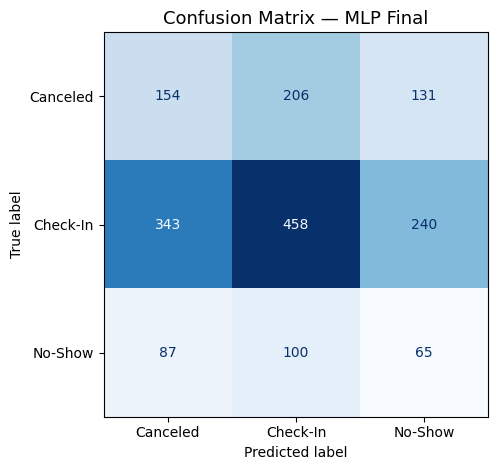

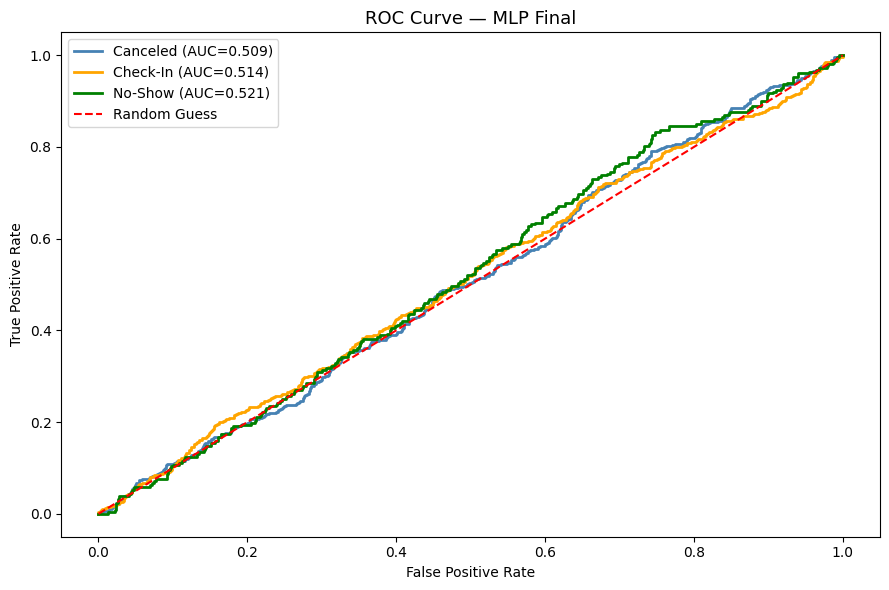

In [18]:
# Change this based on comparison table results
# Options: mlp_baseline, mlp_smote, mlp_rus, mlp_exact,
#          mlp_exact_deep, mlp_rus_deep, mlp_smote_deep

mlp_final = mlp_rus  # default to undersampling — update if another wins

y_pred_final = mlp_final.predict(X_val)
y_prob_final = mlp_final.predict_proba(X_val)

metrics_final = evaluate_model("MLP Final", y_val, y_pred_final,
                                y_prob_final, y_val_bin, le_target.classes_)

---
## **Training Loss Curve**

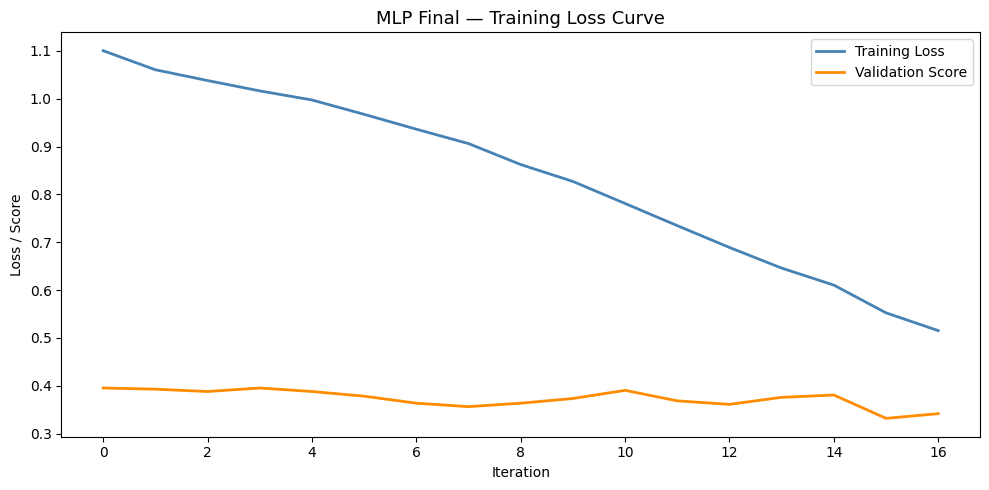

Stopped at iteration 17 (early stopping patience: 15)


In [19]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_final.loss_curve_, color="steelblue", linewidth=2, label="Training Loss")
if hasattr(mlp_final, 'validation_scores_') and mlp_final.validation_scores_ is not None:
    plt.plot(mlp_final.validation_scores_, color="darkorange", linewidth=2, label="Validation Score")
plt.xlabel("Iteration")
plt.ylabel("Loss / Score")
plt.title("MLP Final — Training Loss Curve", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Stopped at iteration {mlp_final.n_iter_} (early stopping patience: 15)")

---
## **Permutation Importance**

Computing permutation importance on validation set...

Top 15 Features by Permutation Importance:
                    feature  importance_mean  importance_std
                  Meal_Type         0.007881        0.009709
                     Adults         0.006394        0.002932
              Discount_Rate         0.005288        0.003843
       Country_region_South         0.005226        0.003630
     Booking_channel_Online         0.003400        0.003793
       Country_region_North         0.003208        0.003757
     Booking_channel_Direct         0.003141        0.002963
               Total_Guests         0.002751        0.004299
          Booking_dayofweek         0.002330        0.003861
          Visted_Previously         0.001894        0.004034
      Hotel_Type_City_Hotel         0.001778        0.002836
              Use_Promotion         0.001540        0.002661
Deposit_type_Non_Refundable         0.001218        0.001364
                  Room_Rate         0.001164    

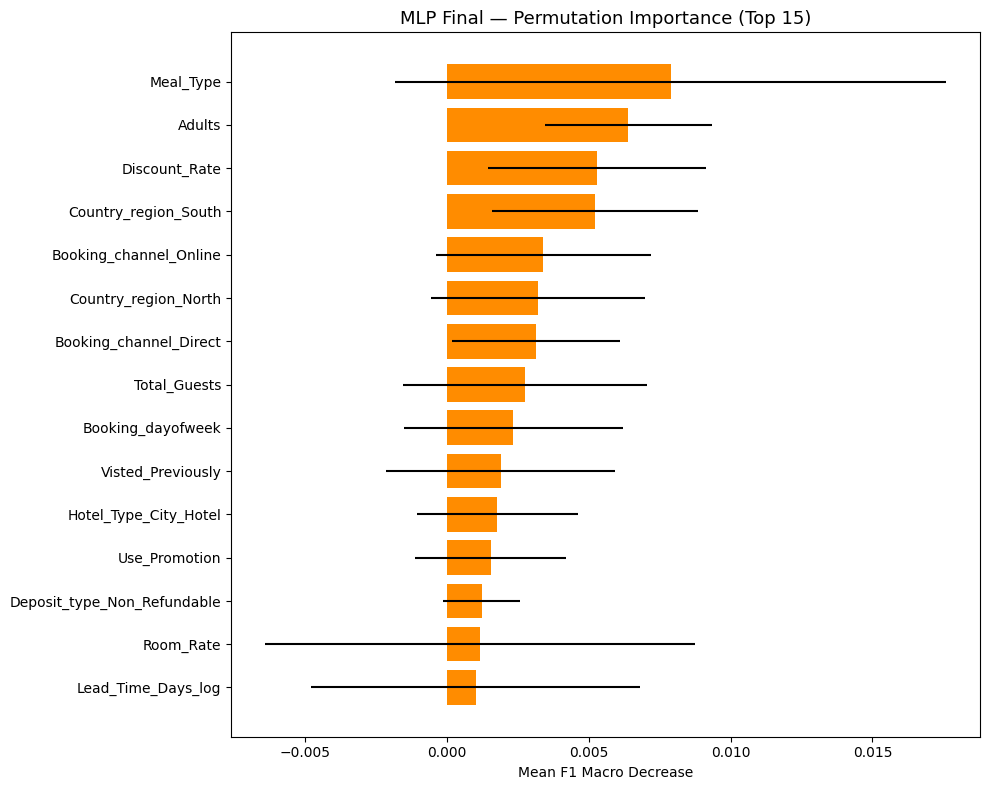

In [20]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance on validation set...")
perm_result = permutation_importance(
    mlp_final, X_val, y_val,
    n_repeats=10, random_state=42,
    scoring="f1_macro", n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 Features by Permutation Importance:")
print(perm_imp.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top15_perm = perm_imp.head(15)
plt.barh(top15_perm["feature"][::-1], top15_perm["importance_mean"][::-1],
         xerr=top15_perm["importance_std"][::-1], color="darkorange")
plt.xlabel("Mean F1 Macro Decrease")
plt.title("MLP Final — Permutation Importance (Top 15)", fontsize=13)
plt.tight_layout()
plt.show()

---
## **Save Model**

In [21]:
# Save model and scaler (both needed for inference)
with open("mlp_final.pkl", "wb") as f:
    pickle.dump(mlp_final, f)

with open("mlp_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved: mlp_final.pkl")
print("Scaler saved: mlp_scaler.pkl")
print(f"\nFinal Metrics:")
for k, v in metrics_final.items():
    print(f"  {k}: {v}")

Model saved: mlp_final.pkl
Scaler saved: mlp_scaler.pkl

Final Metrics:
  name: MLP Final
  accuracy: 0.3795
  precision: 0.3374
  recall: 0.3372
  f1_macro: 0.3276
  roc_auc: 0.5147
